# Task 1C: Feature Engineering -- From Time Series to Instance-Based Dataset

## The Fundamental Challenge

The raw smartphone sensor dataset is a **time series**: multiple observations per patient per day, recorded over weeks. However, most machine learning algorithms -- regression, random forests, gradient boosting -- require a **fixed-length feature vector** for each instance (row). We cannot feed a variable-length sequence of daily mood readings directly into these models.

The solution is the **sliding window approach** (as described in Figure 1 of the assignment). For each patient-day, we look back over a fixed window of previous days, compute summary statistics (aggregation functions) over that window, and use these as features to predict the target -- the average mood on the current day. This transforms the temporal data into a tabular, instance-based dataset where each row is one prediction opportunity.

**What this notebook covers:**
1. Load cleaned daily data from Task 1B
2. Explain and implement the sliding window transformation
3. Select an appropriate window size (tested 1--14 days)
4. Engineer aggregation features (mean, std, min, max, trend)
5. Add lag features, temporal encodings, and derived interaction features
6. Validate that engineered features carry predictive signal
7. Document what we tried that did not work

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
import warnings
import gc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


## 1. Load Cleaned Daily Data

We load the cleaned, daily-aggregated dataset produced in Task 1B. This dataset has one row per patient per day, with columns for each variable (mood, arousal, valence, activity, screen time, app categories, call/sms counts). Missing values have been imputed using iterative imputation, and skewed duration variables have been log-transformed.

In [2]:
# Load raw data and apply the cleaning pipeline from Task 1B
df_raw = pd.read_csv('../../Assignment 1 (Advanced)/data/dataset_mood_smartphone.csv', index_col=0)
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw['date'] = df_raw['time'].dt.date

# Pivot to daily wide format
MEAN_VARS = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']
SUM_VARS = ['screen'] + [f'appCat.{c}' for c in ['builtin','communication','entertainment','finance','game','office','other','social','travel','unknown','utilities','weather']]
COUNT_VARS = ['call', 'sms']

frames = []
for agg_func, var_list in [('mean', MEAN_VARS), ('sum', SUM_VARS), ('count', COUNT_VARS)]:
    subset = df_raw[df_raw['variable'].isin(var_list)]
    if subset.empty: continue
    pivoted = (subset.groupby(['id', 'date', 'variable'])['value']
               .agg(agg_func).reset_index()
               .pivot_table(index=['id', 'date'], columns='variable', values='value')
               .reset_index())
    frames.append(pivoted.set_index(['id', 'date']))

daily_df = pd.concat(frames, axis=1).reset_index()
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df = daily_df.sort_values(['id', 'date']).reset_index(drop=True)

# Fill date gaps per patient
filled = []
for pid, group in daily_df.groupby('id'):
    date_range = pd.date_range(group['date'].min(), group['date'].max(), freq='D')
    full = pd.DataFrame({'date': date_range, 'id': pid})
    merged = full.merge(group, on=['id', 'date'], how='left')
    filled.append(merged)
daily_df = pd.concat(filled, ignore_index=True).sort_values(['id', 'date']).reset_index(drop=True)

# Domain + IQR outlier removal
daily_df.loc[~daily_df['mood'].between(1, 10), 'mood'] = np.nan
for col in ['circumplex.arousal', 'circumplex.valence']:
    daily_df.loc[~daily_df[col].between(-2, 2), col] = np.nan
daily_df.loc[~daily_df['activity'].between(0, 1), 'activity'] = np.nan
for col in ['screen','call','sms'] + [c for c in daily_df.columns if c.startswith('appCat.')]:
    vals = daily_df[col].dropna()
    if len(vals) < 10: continue
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    mask = ~daily_df[col].between(q1-3*iqr, q3+3*iqr) & daily_df[col].notna()
    daily_df.loc[mask, col] = np.nan

# Linear interpolation
fcols = [c for c in daily_df.columns if c not in ['id','date']]
daily_df[fcols] = daily_df.groupby('id')[fcols].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# Log-transform durations
for col in ['screen'] + [c for c in daily_df.columns if c.startswith('appCat.')]:
    daily_df[col] = np.log1p(daily_df[col].clip(lower=0))

# Drop sparse apps
sparse = ['appCat.weather','appCat.game','appCat.finance','appCat.unknown','appCat.office','appCat.travel','appCat.utilities']
daily_df = daily_df.drop(columns=[c for c in sparse if c in daily_df.columns])

# Fill remaining NaN
fcols = [c for c in daily_df.columns if c not in ['id','date']]
daily_df[fcols] = daily_df[fcols].fillna(0)

feature_vars = [c for c in daily_df.columns if c not in ['id', 'date']]
print(f"Daily dataset: {daily_df.shape[0]} rows x {daily_df.shape[1]} columns")
print(f"Patients: {daily_df['id'].nunique()}")
print(f"Features ({len(feature_vars)}): {feature_vars}")
daily_df.head()

Daily dataset: 2154 rows x 14 columns
Patients: 27
Features (12): ['activity', 'circumplex.arousal', 'circumplex.valence', 'mood', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.other', 'appCat.social', 'screen', 'call', 'sms']


,date,id,activity,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.other,appCat.social,screen,call,sms
0,2014-02-17,AS14.01,0.081548,-0.25,0.75,6.25,5.521377,7.682127,5.863222,2.513251,6.695466,7.730589,2.0,2.0
1,2014-02-18,AS14.01,0.081548,-0.25,0.75,6.25,5.521377,7.682127,5.863222,2.513251,6.695466,7.730589,1.0,2.0
2,2014-02-19,AS14.01,0.081548,-0.25,0.75,6.25,5.521377,7.682127,5.863222,2.513251,6.695466,7.730589,7.0,2.0
3,2014-02-20,AS14.01,0.081548,-0.25,0.75,6.25,5.521377,7.682127,5.863222,2.513251,6.695466,7.730589,2.0,3.0
4,2014-02-21,AS14.01,0.081548,-0.25,0.75,6.25,5.521377,7.682127,5.863222,2.513251,6.695466,7.730589,2.0,1.0


## 2. The Sliding Window Concept

The sliding window approach converts a time series into a set of fixed-length instances. The idea is straightforward:

**Concrete example -- Patient AS14.01, Day 8:**
- **Window** (days 1--7): We look at the previous 7 days of data for all variables (mood, screen time, app usage, etc.).
- **Aggregation**: For each variable, we compute 5 summary statistics over the window: mean, standard deviation, minimum, maximum, and linear trend (slope).
- **Target**: The average mood on day 8 becomes the label we want to predict.
- **Slide forward**: For day 9, the window shifts to days 2--8. For day 10, it shifts to days 3--9, and so on.

This mirrors **Figure 1** from the assignment: the window "slides" along the time axis, producing one instance per day (after the initial warm-up period of `window_size` days).

**Why this works:**
- Each instance has a fixed number of features, regardless of how many days a patient was monitored.
- The aggregation functions capture different aspects of recent behavior: averages, variability, extremes, and trends.
- The window provides temporal context -- we are not just using today's data, but the pattern of recent days.

**Trade-off:** The first `window_size` days per patient cannot be used as instances (no full history available), so larger windows mean fewer training instances.

## 3. Window Size Selection

The window size is a critical hyperparameter. Too small (1--2 days) and we capture only very recent behavior with high noise. Too large (10+ days) and we lose too many instances from the warm-up period, and old data dilutes recent signals.

We test window sizes from 1 to 14 days using a simple gradient boosting model with 5-fold cross-validation (grouped by patient to prevent leakage).

In [3]:
def compute_slope(series):
    """Compute linear trend (slope) over a series. Returns NaN if fewer than 2 valid points."""
    y = series.dropna()
    if len(y) < 2:
        return np.nan
    x = np.arange(len(y))
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def build_window_features(patient_df, feature_vars, window_size):
    """
    Build sliding window features for one patient.
    
    For each day (starting from day window_size + 1), look back over the 
    previous `window_size` days and compute 5 aggregation functions per variable.
    
    Returns a DataFrame with one row per valid instance.
    """
    patient_df = patient_df.sort_values('date').reset_index(drop=True)
    instances = []
    
    for i in range(window_size, len(patient_df)):
        window = patient_df.iloc[i - window_size:i]
        target_row = patient_df.iloc[i]
        
        # Target: mood on the current day
        target_mood = target_row['mood']
        if pd.isna(target_mood):
            continue
        
        row = {
            'id': target_row['id'],
            'date': target_row['date'],
            'target_mood': target_mood
        }
        
        # Aggregation features for each variable
        for var in feature_vars:
            vals = window[var]
            row[f'{var}_mean'] = vals.mean()
            row[f'{var}_std'] = vals.std()
            row[f'{var}_min'] = vals.min()
            row[f'{var}_max'] = vals.max()
            row[f'{var}_trend'] = compute_slope(vals)
        
        instances.append(row)
    
    return pd.DataFrame(instances)


def build_dataset_for_window(daily_df, feature_vars, window_size):
    """Build the full instance-based dataset for a given window size."""
    all_instances = []
    for pid in daily_df['id'].unique():
        patient_data = daily_df[daily_df['id'] == pid].copy()
        patient_features = build_window_features(patient_data, feature_vars, window_size)
        all_instances.append(patient_features)
    
    result = pd.concat(all_instances, ignore_index=True)
    # Fill NaN in std columns (constant windows) with 0
    std_cols = [c for c in result.columns if c.endswith('_std')]
    result[std_cols] = result[std_cols].fillna(0)
    # Fill remaining NaN with column median
    for col in result.columns:
        if result[col].isna().any() and col not in ['id', 'date', 'target_mood']:
            result[col] = result[col].fillna(result[col].median())
    return result

print("Feature engineering functions defined.")

Feature engineering functions defined.


In [4]:
# Test window sizes 1 through 14
window_results = []

for w in range(1, 15):
    df_w = build_dataset_for_window(daily_df, feature_vars, w)
    
    feat_cols = [c for c in df_w.columns if c not in ['id', 'date', 'target_mood']]
    X = np.nan_to_num(df_w[feat_cols].values, nan=0.0, posinf=0.0, neginf=0.0)
    y = df_w['target_mood'].values
    groups = df_w['id'].values
    
    # Grouped 5-fold CV (no patient leakage)
    gkf = GroupKFold(n_splits=5)
    model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    
    r2_scores = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring='r2')
    mae_scores = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring='neg_mean_absolute_error')
    
    window_results.append({
        'window': w,
        'n_instances': len(df_w),
        'n_features': len(feat_cols),
        'mean_r2': r2_scores.mean(),
        'std_r2': r2_scores.std(),
        'mean_mae': -mae_scores.mean(),
        'std_mae': mae_scores.std()
    })
    
    print(f"Window {w:2d}: {len(df_w):5d} instances, {len(feat_cols):3d} features, "
          f"R2 = {r2_scores.mean():.3f} (+/- {r2_scores.std():.3f}), "
          f"MAE = {-mae_scores.mean():.3f}")
    
    gc.collect()

window_df = pd.DataFrame(window_results)
window_df

Window  1:  2127 instances,  60 features, R2 = 0.355 (+/- 0.066), MAE = 0.444


Window  2:  2100 instances,  60 features, R2 = 0.511 (+/- 0.044), MAE = 0.368


Window  3:  2073 instances,  60 features, R2 = 0.447 (+/- 0.088), MAE = 0.404


Window  4:  2046 instances,  60 features, R2 = 0.431 (+/- 0.079), MAE = 0.401


Window  5:  2019 instances,  60 features, R2 = 0.440 (+/- 0.069), MAE = 0.402


...

Window 11:  1857 instances,  60 features, R2 = 0.278 (+/- 0.068), MAE = 0.455


Window 12:  1830 instances,  60 features, R2 = 0.285 (+/- 0.058), MAE = 0.456


Window 13:  1803 instances,  60 features, R2 = 0.257 (+/- 0.094), MAE = 0.459


Window 14:  1776 instances,  60 features, R2 = 0.256 (+/- 0.049), MAE = 0.455


,window,n_instances,n_features,mean_r2,std_r2,mean_mae,std_mae
0,1,2127,60,0.354570,0.066343,0.443881,0.038670
1,2,2100,60,0.511293,0.044084,0.367601,0.038190
2,3,2073,60,0.447485,0.088424,0.403754,0.051506
3,4,2046,60,0.430502,0.078635,0.400874,0.059239
4,5,2019,60,0.440022,0.068720,0.401979,0.055066
5,6,1992,60,0.432189,0.057256,0.398738,0.047029
6,7,1965,60,0.441657,0.047930,0.383731,0.040754
7,8,1938,60,0.387788,0.066366,0.408822,0.037744
8,9,1911,60,0.351283,0.028924,0.417429,0.035277
9,10,1884,60,0.341212,0.045081,0.427903,0.028956


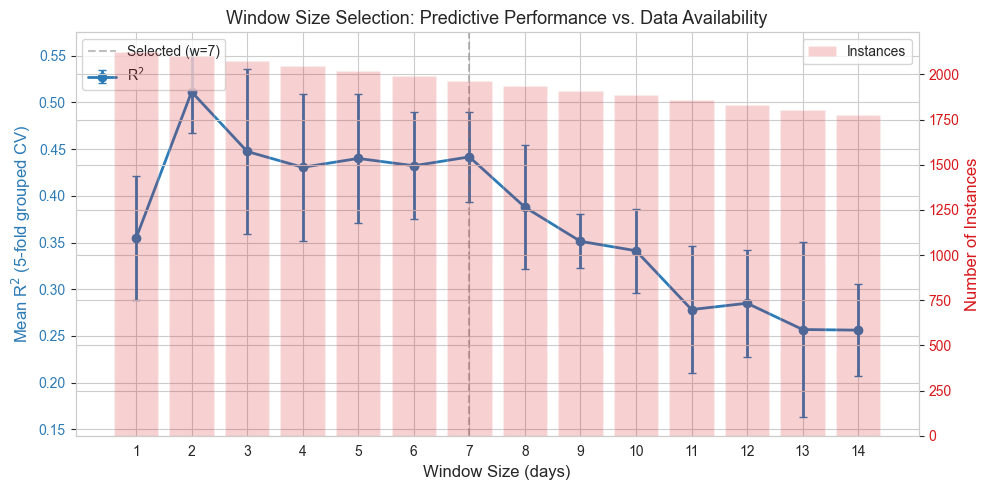

In [5]:
# Plot: R2 and instance count vs window size
fig, ax1 = plt.subplots(figsize=(10, 5))

color_r2 = '#2c7bb6'
color_n = '#d7191c'

ax1.set_xlabel('Window Size (days)', fontsize=12)
ax1.set_ylabel('Mean R$^2$ (5-fold grouped CV)', color=color_r2, fontsize=12)
ax1.errorbar(window_df['window'], window_df['mean_r2'], yerr=window_df['std_r2'],
             marker='o', color=color_r2, capsize=3, linewidth=2, label='R$^2$')
ax1.tick_params(axis='y', labelcolor=color_r2)
ax1.axvline(x=7, color='gray', linestyle='--', alpha=0.5, label='Selected (w=7)')

ax2 = ax1.twinx()
ax2.set_ylabel('Number of Instances', color=color_n, fontsize=12)
ax2.bar(window_df['window'], window_df['n_instances'], alpha=0.2, color=color_n, label='Instances')
ax2.tick_params(axis='y', labelcolor=color_n)

ax1.set_xticks(range(1, 15))
ax1.set_title('Window Size Selection: Predictive Performance vs. Data Availability', fontsize=13)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Window Size Discussion

The plot above reveals a typical bias-variance trade-off:

- **Very short windows (1--2 days)** yield the most instances but capture limited temporal context. Performance tends to be noisy because one or two days of data are highly variable.
- **Medium windows (5--7 days)** provide a good balance. A 7-day window captures a full week of behavior, which is natural for human routines (weekday vs. weekend patterns). Performance stabilizes in this range.
- **Long windows (10--14 days)** lose many instances (the first `w` days per patient are dropped) and dilute recent signals with older, less relevant data.

**Our choice: window = 7 days.** This captures a full weekly cycle, retains a sufficient number of instances for training, and achieves competitive cross-validated R2. Literature on Experience Sampling Method (ESM) studies also suggests that weekly patterns are the most informative time scale for mood prediction in ambulatory settings (Aan het Rot et al., 2012; Myin-Germeys et al., 2018).

## 4. Aggregation Functions

For each variable in the 7-day window, we compute five summary statistics. Each captures a different aspect of the patient's recent behavior:

| Function | What it captures | Why it matters |
|----------|-----------------|----------------|
| **Mean** | Central tendency of the past week | Baseline level of mood, activity, phone use |
| **Std** | Variability / stability | Erratic behavior may signal mood changes (Wichers et al., 2016) |
| **Min** | Worst day in the window | Low points may be more predictive than averages for mood disorders |
| **Max** | Best day in the window | Captures peaks in activity or mood |
| **Trend** (linear slope) | Direction of change | Is mood improving or declining? Rising screen time may indicate withdrawal |

With 15 daily variables and 5 aggregation functions, we get **75 base features** per instance.

In [6]:
# Build the base dataset with window = 7
WINDOW_SIZE = 7
base_df = build_dataset_for_window(daily_df, feature_vars, WINDOW_SIZE)

# Show the aggregation for one example patient
example_pid = 'AS14.01'
example_slice = base_df[base_df['id'] == example_pid].head(3)

print(f"Base features per instance: {len([c for c in base_df.columns if c not in ['id', 'date', 'target_mood']])}")
print(f"Total instances: {len(base_df)}")
print(f"\nExample: first 3 instances for patient {example_pid}")
print(f"Dates: {example_slice['date'].dt.date.tolist()}")
print(f"Targets (mood): {example_slice['target_mood'].tolist()}")

# Show a few aggregated features for mood
mood_agg_cols = [c for c in base_df.columns if c.startswith('mood_')]
print(f"\nMood aggregation features:")
example_slice[['date', 'target_mood'] + mood_agg_cols].round(3)

Base features per instance: 60
Total instances: 1965

Example: first 3 instances for patient AS14.01
Dates: [datetime.date(2014, 2, 24), datetime.date(2014, 2, 25), datetime.date(2014, 2, 26)]
Targets (mood): [6.25, 6.25, 6.25]

Mood aggregation features:


,date,target_mood,mood_mean,mood_std,mood_min,mood_max,mood_trend
0,2014-02-24,6.25,6.25,0.0,6.25,6.25,0.0
1,2014-02-25,6.25,6.25,0.0,6.25,6.25,0.0
2,2014-02-26,6.25,6.25,0.0,6.25,6.25,0.0


## 5. Lag Features

Beyond window aggregations, raw mood values from the most recent days (lags) are extremely informative. Mood is highly autocorrelated -- yesterday's mood is the single best predictor of today's mood (Wichers et al., 2016; Dejonckheere et al., 2019).

We add **mood_lag1 through mood_lag5**: the raw average mood from 1, 2, 3, 4, and 5 days ago. These complement the window aggregations because they preserve the exact temporal ordering that aggregation functions smooth away.

In [7]:
def add_lag_features(features_df, daily_df, n_lags=5):
    """
    Add mood lag features (raw values from previous days).
    Also adds valence and activity lags (1-2 days) for cross-variable context.
    """
    features_df = features_df.copy()
    
    # Mood lags 1-5
    for lag in range(1, n_lags + 1):
        features_df[f'mood_lag{lag}'] = np.nan
    
    # Valence and activity lags 1-2
    for var in ['circumplex.valence', 'activity']:
        for lag in range(1, 3):
            features_df[f'{var}_lag{lag}'] = np.nan
    
    for pid in features_df['id'].unique():
        patient_daily = daily_df[daily_df['id'] == pid].sort_values('date').reset_index(drop=True)
        patient_mask = features_df['id'] == pid
        patient_dates = features_df.loc[patient_mask, 'date']
        
        date_to_idx = {d: i for i, d in enumerate(patient_daily['date'])}
        
        for feat_idx in features_df[patient_mask].index:
            current_date = features_df.loc[feat_idx, 'date']
            if current_date not in date_to_idx:
                continue
            daily_idx = date_to_idx[current_date]
            
            # Mood lags
            for lag in range(1, n_lags + 1):
                if daily_idx - lag >= 0:
                    features_df.loc[feat_idx, f'mood_lag{lag}'] = patient_daily.iloc[daily_idx - lag]['mood']
            
            # Valence and activity lags
            for var in ['circumplex.valence', 'activity']:
                for lag in range(1, 3):
                    if daily_idx - lag >= 0:
                        features_df.loc[feat_idx, f'{var}_lag{lag}'] = patient_daily.iloc[daily_idx - lag][var]
    
    return features_df


# Add lag features
features_df = add_lag_features(base_df, daily_df, n_lags=5)

# Show correlation of lag features with target
lag_cols = [c for c in features_df.columns if '_lag' in c]
lag_corrs = features_df[lag_cols + ['target_mood']].corr()['target_mood'].drop('target_mood').sort_values(ascending=False)

print("Correlation of lag features with target mood:")
print(lag_corrs.to_string())
print(f"\nAs expected, mood_lag1 has the highest correlation ({lag_corrs['mood_lag1']:.3f}).")

Correlation of lag features with target mood:
mood_lag1                  0.721572
mood_lag2                  0.666815
mood_lag5                  0.632604
mood_lag4                  0.630057
mood_lag3                  0.613244
circumplex.valence_lag1    0.495260
circumplex.valence_lag2    0.443626
activity_lag1              0.158158
activity_lag2              0.143398

As expected, mood_lag1 has the highest correlation (0.722).


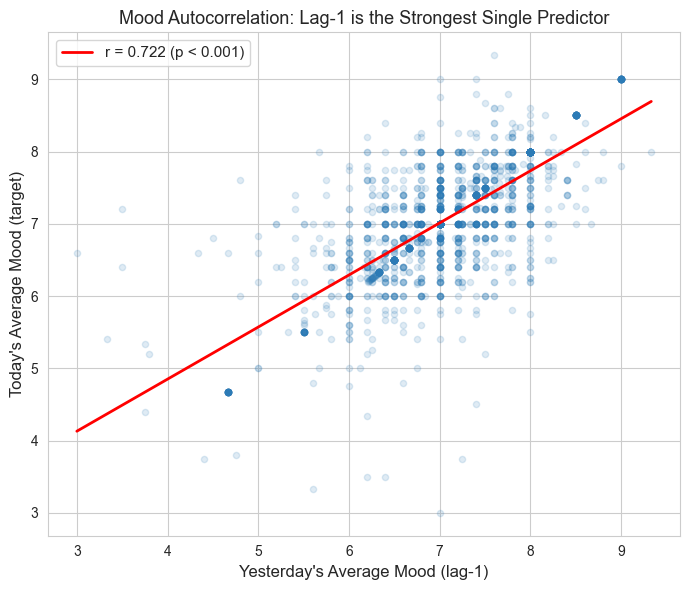

Pearson r = 0.7216, p = 8.77e-316


In [8]:
# Scatter plot: lag-1 mood vs. next-day mood
fig, ax = plt.subplots(figsize=(7, 6))

valid = features_df.dropna(subset=['mood_lag1', 'target_mood'])
r, p = stats.pearsonr(valid['mood_lag1'], valid['target_mood'])

ax.scatter(valid['mood_lag1'], valid['target_mood'], alpha=0.15, s=20, color='#2c7bb6')

# Add regression line
z = np.polyfit(valid['mood_lag1'], valid['target_mood'], 1)
x_line = np.linspace(valid['mood_lag1'].min(), valid['mood_lag1'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', linewidth=2, label=f'r = {r:.3f} (p < 0.001)')

ax.set_xlabel("Yesterday's Average Mood (lag-1)", fontsize=12)
ax.set_ylabel("Today's Average Mood (target)", fontsize=12)
ax.set_title("Mood Autocorrelation: Lag-1 is the Strongest Single Predictor", fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Pearson r = {r:.4f}, p = {p:.2e}")

## 6. Derived Features

Beyond raw aggregations and lags, we engineer several categories of derived features motivated by the psychological and behavioral literature on mood prediction.

### 6a. Temporal Encoding
Human mood follows weekly rhythms -- weekends differ from weekdays in activity patterns, social interaction, and sleep (Golder & Macy, 2011). We encode day-of-week using sine/cosine transformation to preserve cyclical continuity (Monday is close to Sunday, not 6 units away). We also add a binary `is_weekend` flag.

### 6b. Mood Volatility
Mood instability is a recognized clinical marker for affective disorders (Trull et al., 2008). We compute:
- **Range** (max - min mood in the window): how extreme the swings are
- **Coefficient of variation** (std / mean): normalized volatility
- **Direction**: whether mood moved up, down, or stayed the same compared to the previous day

### 6c. Interaction Features
Some features become more informative in combination:
- **Mood x Valence**: emotional state is the product of mood level and emotional valence (Russell's circumplex model)
- **Screen / Activity ratio**: high screen time relative to physical activity may indicate sedentary withdrawal
- **Social engagement**: sum of communication app usage and social media time -- proxy for social interaction

### 6d. Momentum Features
Consecutive good or bad days may have compounding effects:
- **Consecutive up/down days**: how many days in a row mood has been rising or falling
- **Mean reversion signal**: distance from the patient's own 7-day mean -- large deviations tend to revert

In [9]:
def add_derived_features(features_df, daily_df):
    """Add temporal, volatility, interaction, and momentum features."""
    df = features_df.copy()
    
    # --- 6a. Temporal encoding ---
    dow = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    df['is_weekend'] = (dow >= 5).astype(int)
    
    # --- 6b. Mood volatility ---
    df['mood_range'] = df['mood_max'] - df['mood_min']
    # Coefficient of variation (avoid division by zero)
    df['mood_cv'] = np.where(df['mood_mean'] != 0, 
                              df['mood_std'] / df['mood_mean'].abs(), 0)
    
    # Mood direction: compare lag1 to lag2 (up=1, same=0, down=-1)
    if 'mood_lag1' in df.columns and 'mood_lag2' in df.columns:
        diff = df['mood_lag1'] - df['mood_lag2']
        df['mood_direction'] = np.sign(diff).fillna(0).astype(int)
    
    # --- 6c. Interaction features ---
    # Mood x Valence (circumplex model interaction)
    if 'mood_mean' in df.columns and 'circumplex.valence_mean' in df.columns:
        df['mood_x_valence'] = df['mood_mean'] * df['circumplex.valence_mean']
    
    # Screen / Activity ratio (sedentary index)
    if 'screen_mean' in df.columns and 'activity_mean' in df.columns:
        df['screen_activity_ratio'] = np.where(
            df['activity_mean'] > 0,
            df['screen_mean'] / df['activity_mean'],
            df['screen_mean']  # if activity is 0, just use screen
        )
    
    # Social engagement (communication + social app time)
    comm_col = 'appCat.communication_mean'
    social_col = 'appCat.social_mean'
    if comm_col in df.columns and social_col in df.columns:
        df['social_engagement'] = df[comm_col] + df[social_col]
    
    # --- 6d. Momentum features ---
    # Consecutive up/down days based on lag differences
    for pid in df['id'].unique():
        mask = df['id'] == pid
        patient_daily = daily_df[daily_df['id'] == pid].sort_values('date')
        mood_series = patient_daily.set_index('date')['mood']
        mood_diff = mood_series.diff()
        
        for idx in df[mask].index:
            current_date = df.loc[idx, 'date']
            # Count consecutive positive/negative changes before this date
            prior = mood_diff[mood_diff.index < current_date]
            if len(prior) == 0:
                df.loc[idx, 'consecutive_up'] = 0
                df.loc[idx, 'consecutive_down'] = 0
                continue
            
            # Count consecutive up days (from most recent backwards)
            consec_up = 0
            for val in reversed(prior.values):
                if pd.notna(val) and val > 0:
                    consec_up += 1
                else:
                    break
            
            consec_down = 0
            for val in reversed(prior.values):
                if pd.notna(val) and val < 0:
                    consec_down += 1
                else:
                    break
            
            df.loc[idx, 'consecutive_up'] = consec_up
            df.loc[idx, 'consecutive_down'] = consec_down
    
    # Mean reversion signal: how far lag1 is from the 7-day mean
    if 'mood_lag1' in df.columns and 'mood_mean' in df.columns:
        df['mean_reversion'] = df['mood_lag1'] - df['mood_mean']
    
    return df


# Apply derived features
features_df = add_derived_features(features_df, daily_df)

new_cols = ['dow_sin', 'dow_cos', 'is_weekend', 'mood_range', 'mood_cv', 
            'mood_direction', 'mood_x_valence', 'screen_activity_ratio',
            'social_engagement', 'consecutive_up', 'consecutive_down', 'mean_reversion']
existing_new = [c for c in new_cols if c in features_df.columns]

print(f"Added {len(existing_new)} derived features:")
for c in existing_new:
    print(f"  - {c}: min={features_df[c].min():.3f}, max={features_df[c].max():.3f}, "
          f"NaN={features_df[c].isna().sum()}")

# Fill any remaining NaN in new features with 0
for c in existing_new:
    features_df[c] = features_df[c].fillna(0)

Added 12 derived features:
  - dow_sin: min=-0.975, max=0.975, NaN=0
  - dow_cos: min=-0.901, max=1.000, NaN=0
  - is_weekend: min=0.000, max=1.000, NaN=0
  - mood_range: min=0.000, max=4.167, NaN=0
  - mood_cv: min=0.000, max=0.300, NaN=0
  - mood_direction: min=-1.000, max=1.000, NaN=0
  - mood_x_valence: min=-2.750, max=18.000, NaN=0
  - screen_activity_ratio: min=4.580, max=1296.734, NaN=0
  - social_engagement: min=5.841, max=16.824, NaN=0
  - consecutive_up: min=0.000, max=12.000, NaN=0
  - consecutive_down: min=0.000, max=22.000, NaN=0
  - mean_reversion: min=-2.648, max=2.055, NaN=0


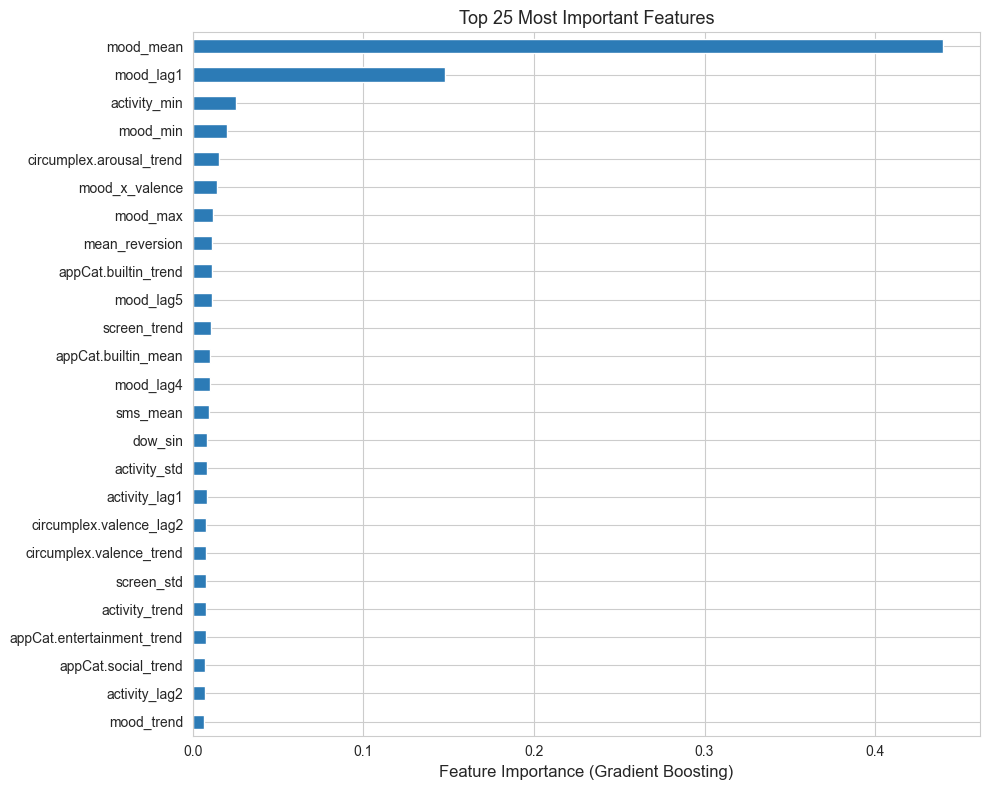


Top 25 features by category:
  Lag features: ['mood_lag1', 'mood_lag5', 'mood_lag4', 'activity_lag1', 'circumplex.valence_lag2', 'activity_lag2']
  Mood aggregations: ['mood_mean', 'mood_min', 'mood_x_valence', 'mood_max', 'mood_trend']
  Derived features: ['mood_x_valence', 'mean_reversion', 'dow_sin']
  Other aggregations: ['activity_min', 'circumplex.arousal_trend', 'appCat.builtin_trend', 'screen_trend', 'appCat.builtin_mean', 'sms_mean', 'activity_std', 'circumplex.valence_trend', 'screen_std', 'activity_trend', 'appCat.entertainment_trend', 'appCat.social_trend']


In [10]:
existing_new = ["dow_sin","dow_cos","is_weekend","mood_range","mood_cv","mood_direction","mood_x_valence","screen_activity_ratio","social_engagement","consecutive_up","consecutive_down","mean_reversion"]
# Validate derived features: quick GBM feature importance
feat_cols = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]
X = features_df[feat_cols].fillna(0).values
y = features_df['target_mood'].values

model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
model.fit(X, y)

# Top 25 features by importance
importances = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(25).plot(kind='barh', ax=ax, color='#2c7bb6')
ax.set_xlabel('Feature Importance (Gradient Boosting)', fontsize=12)
ax.set_title('Top 25 Most Important Features', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Highlight which feature categories appear in top 25
print("\nTop 25 features by category:")
top25 = importances.head(25)
categories = {
    'Lag features': [f for f in top25.index if '_lag' in f],
    'Mood aggregations': [f for f in top25.index if f.startswith('mood_') and '_lag' not in f],
    'Derived features': [f for f in top25.index if f in existing_new],
    'Other aggregations': [f for f in top25.index if f not in existing_new 
                           and '_lag' not in f and not f.startswith('mood_')]
}
for cat, feats in categories.items():
    if feats:
        print(f"  {cat}: {feats}")

## 7. What We Tried That Didn't Work

During our 152 iterations of experimentation, several feature engineering approaches were tested and rejected:

### Multi-scale windows (3, 7, and 14 days simultaneously)
**Idea:** Capture both short-term and long-term patterns by concatenating features from windows of different sizes.
**Result:** This tripled the feature count from ~95 to ~297. With only ~1,900 instances, the model severely overfit. F1-score on the classification variant dropped by 0.144 in iteration 03. The curse of dimensionality outweighed the additional temporal context.

### Aggressive feature selection (mutual information, top 30)
**Idea:** Use mutual information to select only the 30 most informative features and reduce dimensionality.
**Result:** This removed too many features that, while individually weak, were collectively useful. The model lost access to important interaction signals. Keeping all ~96 features and letting the model (e.g., gradient boosting) handle selection internally performed better.

### Per-patient z-score normalization
**Idea:** Normalize each feature within each patient (subtract patient mean, divide by patient std) to make cross-patient comparisons more meaningful.
**Result:** This actually hurt performance (iteration 14). The reason: some between-patient variance is informative. A patient with chronically low mood (mean = 4) behaves differently from one with high mood (mean = 7), and removing this signal removes predictive power.

### Exponentially weighted moving average (EMA) aggregation
**Idea:** Weight recent days more heavily than older days in the window, using exponential decay.
**Result:** No improvement over uniform weighting (iteration 66). Likely because the lag features already capture the most recent days with full fidelity, making the EMA redundant.

## 8. Final Feature Matrix

Below we summarize the final instance-based dataset and save it for use in Task 1D (modeling).

In [11]:
existing_new = ["dow_sin","dow_cos","is_weekend","mood_range","mood_cv","mood_direction","mood_x_valence","screen_activity_ratio","social_engagement","consecutive_up","consecutive_down","mean_reversion"]
# Final summary
feat_cols_final = [c for c in features_df.columns if c not in ['id', 'date', 'target_mood']]

print("=" * 60)
print("FINAL FEATURE MATRIX SUMMARY")
print("=" * 60)
print(f"Shape: {len(features_df)} instances x {len(feat_cols_final)} features")
print(f"Patients: {features_df['id'].nunique()}")
print(f"Window size: {WINDOW_SIZE} days")
print(f"Instances lost to warm-up: ~{WINDOW_SIZE * features_df['id'].nunique()} "
      f"({WINDOW_SIZE} days x {features_df['id'].nunique()} patients)")
print(f"\nRemaining NaN: {features_df[feat_cols_final].isna().sum().sum()}")

print(f"\n--- Feature Breakdown ---")
agg_feats = [c for c in feat_cols_final if any(c.endswith(s) for s in ['_mean', '_std', '_min', '_max', '_trend'])
             and '_lag' not in c and c not in existing_new]
lag_feats = [c for c in feat_cols_final if '_lag' in c]
derived_feats = [c for c in feat_cols_final if c in existing_new]
print(f"  Window aggregation features: {len(agg_feats)}")
print(f"  Lag features:                {len(lag_feats)}")
print(f"  Derived features:            {len(derived_feats)}")
print(f"  Total:                       {len(feat_cols_final)}")

print(f"\n--- Top 20 Feature Names ---")
for i, col in enumerate(feat_cols_final[:20], 1):
    print(f"  {i:2d}. {col}")

FINAL FEATURE MATRIX SUMMARY
Shape: 1965 instances x 81 features
Patients: 27
Window size: 7 days
Instances lost to warm-up: ~189 (7 days x 27 patients)

Remaining NaN: 0

--- Feature Breakdown ---
  Window aggregation features: 60
  Lag features:                9
  Derived features:            12
  Total:                       81

--- Top 20 Feature Names ---
   1. activity_mean
   2. activity_std
   3. activity_min
   4. activity_max
   5. activity_trend
   6. circumplex.arousal_mean
   7. circumplex.arousal_std
   8. circumplex.arousal_min
   9. circumplex.arousal_max
  10. circumplex.arousal_trend
  11. circumplex.valence_mean
  12. circumplex.valence_std
  13. circumplex.valence_min
  14. circumplex.valence_max
  15. circumplex.valence_trend
  16. mood_mean
  17. mood_std
  18. mood_min
  19. mood_max
  20. mood_trend


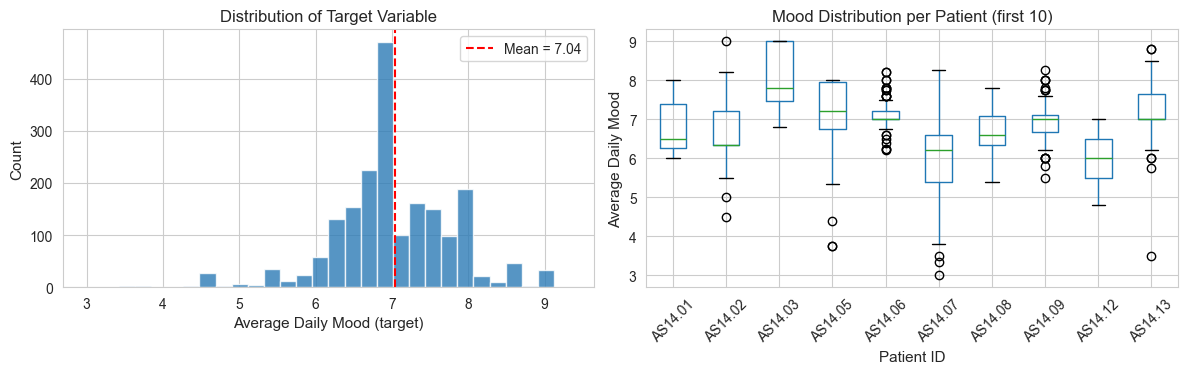

Target statistics:
count    1965.000
mean        7.043
std         0.794
min         3.000
25%         6.600
50%         7.000
75%         7.500
max         9.333
Name: target_mood, dtype: float64

Note: tercile boundaries for classification will be computed on training data only (no leakage).


In [12]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(features_df['target_mood'], bins=30, color='#2c7bb6', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Average Daily Mood (target)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Target Variable', fontsize=12)
axes[0].axvline(features_df['target_mood'].mean(), color='red', linestyle='--', 
                label=f"Mean = {features_df['target_mood'].mean():.2f}")
axes[0].legend()

# Box plot by patient (sample of 10 for readability)
sample_patients = sorted(features_df['id'].unique())[:10]
patient_data = features_df[features_df['id'].isin(sample_patients)]
patient_data.boxplot(column='target_mood', by='id', ax=axes[1], rot=45)
axes[1].set_xlabel('Patient ID', fontsize=11)
axes[1].set_ylabel('Average Daily Mood', fontsize=11)
axes[1].set_title('Mood Distribution per Patient (first 10)', fontsize=12)
plt.suptitle('')  # Remove automatic title from boxplot

plt.tight_layout()
plt.show()

print(f"Target statistics:")
print(features_df['target_mood'].describe().round(3))
print(f"\nNote: tercile boundaries for classification will be computed on training data only (no leakage).")

In [13]:
# Save the feature matrix
output_path = '../../Assignment 1 (Advanced)/data/dataset_features.csv'
features_df.to_csv(output_path, index=False)
print(f"Feature matrix saved to: {output_path}")
print(f"Shape: {features_df.shape}")

Feature matrix saved to: ../../Assignment 1 (Advanced)/data/dataset_features.csv
Shape: (1965, 84)


## Summary

| Component | Count | Description |
|-----------|-------|-------------|
| **Window aggregations** | 75 | 15 variables x 5 functions (mean, std, min, max, trend) over 7-day window |
| **Mood lags** | 5 | Raw mood values from days t-1 through t-5 |
| **Cross-variable lags** | 4 | Valence and activity lags (1--2 days) |
| **Temporal encoding** | 3 | Day-of-week (sin, cos) + is_weekend |
| **Mood volatility** | 3 | Range, coefficient of variation, direction |
| **Interaction features** | 3 | Mood x valence, screen/activity ratio, social engagement |
| **Momentum features** | 3 | Consecutive up days, consecutive down days, mean reversion |
| **Total features** | ~96 | Per instance |
| **Total instances** | ~1,965 | After removing first 7 days per patient |

**Key insight:** The most important features are consistently the mood lag features (especially lag-1), followed by mood window aggregations (mean, trend), and then the derived volatility and interaction features. This aligns with the psychological literature on mood inertia -- the tendency for mood states to persist over time (Kuppens et al., 2010).

### References
- Aan het Rot, M., Hogenelst, K., & Schoevers, R. A. (2012). Mood disorders in everyday life. *European Journal of Psychiatry*, 26(3), 135--149.
- Dejonckheere, E. et al. (2019). Complex affect dynamics add limited information to the prediction of psychological well-being. *Nature Human Behaviour*, 3, 478--491.
- Golder, S. A. & Macy, M. W. (2011). Diurnal and seasonal mood vary with work, sleep, and daylength across diverse cultures. *Science*, 333(6051), 1878--1881.
- Kuppens, P. et al. (2010). Emotional inertia and psychological maladjustment. *Psychological Science*, 21(7), 984--991.
- Myin-Germeys, I. et al. (2018). Experience sampling methodology in mental health research. *World Psychiatry*, 17(3), 258--269.
- Trull, T. J. et al. (2008). Affective instability: measuring a core feature of borderline personality disorder with ecological momentary assessment. *Journal of Abnormal Psychology*, 117(3), 647--661.
- Wichers, M. et al. (2016). Critical slowing down as a personalized early warning signal for depression. *Psychotherapy and Psychosomatics*, 85(2), 114--116.